# Error Label Statistics

This notebook summarizes `error_label` counts from `annotations/summary_hallucination/Qualitative_Direct.csv`.

It reports:
- Overall row-level label distribution
- Model-wise row-level label distribution
- Decomposed taxonomy-level counts for multi-label rows such as `OMIT;H-DISC`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    target = Path("annotations/summary_hallucination/Qualitative_Direct.csv")
    for path in [start, *start.parents]:
        if (path / target).exists():
            return path
    raise FileNotFoundError(f"Could not find {target} from {start}")


REPO_ROOT = find_repo_root()
CSV_PATH = REPO_ROOT / "annotations/summary_hallucination/Qualitative_Direct.csv"

df = pd.read_csv(CSV_PATH)
df.head()

,model_name,sample_index,error_label,Review_Notes,reference,prediction,dialogue,rouge1,rouge2,rougeL,bs_f1_raw,informativeness,clarity,plausibility,faithfulness,Length Ratio
0,aya-expanse:8b,0,NO-ERROR,대화 내용과 일치하며 뚜렷한 오류가 없습니다.,佩顿给麦克斯提供了卖衣服的网站。他喜欢浏览、试穿衣服，但不一定都会买。他经常买衣服和书，因为...,麦克斯问派顿是否知道哪里可以买到好衣服。派顿列出了几个网站，但表示通常会从两个或三个网站购买...,Max: Know any good sites to buy clothes from?\...,34.72,12.68,26.39,72.35,3.747849,3.144308,3.576921,3.386819,3.301887
1,aya-expanse:8b,1,H-CIRC,마을의 사람 수와 인형/조각상 수의 비교가 반대로 요약되었습니다.,凯利很害怕芬兰雕塑花园里的人物，因为她觉得那些人物的脸非常病态。对奥利来说，这就像日本的人偶...,奥利、凯利、米奇和杰西卡在聊天，分享他们认为最可怕或最令人印象深刻的地方。凯利提到芬兰的一个...,"Ollie: Okay, Kelly! Ur up nxt!\n Kelly: Me? I ...",24.00,3.25,16.00,66.78,2.662900,3.738938,4.115586,3.712319,2.709091
2,aya-expanse:8b,2,NO-ERROR,대화 내용과 일치하며 뚜렷한 오류가 없습니다.,贝拉和埃里克拒绝了一个客户的要求。他们老板很赞赏这个决定。他会吸引新的客户来。,埃里克问贝拉今天老板房间里发生了什么，老板是否生气。贝拉回答说老板并没有生气，反而对他们拒绝...,"Eric: Hey Bella, What happened today in boss's...",36.59,0.00,21.95,70.33,3.844766,3.566477,3.631886,3.107535,2.769231
3,aya-expanse:8b,3,LANG,요약문이 아니라 대화문을 그대로 번역한 형식입니다.,玛丽的钱用完了，卡特打算一小时后借给她一点。,玛丽：嘿，我有点缺钱，能借我几百元吗？\n 卡特：好的，给我一个小时，我在火车站。\n 玛丽...,"Mary: hey, im kinda broke, lend me a few box\n...",20.83,4.35,16.67,68.02,3.704244,4.922638,4.911533,4.406132,2.090909
4,aya-expanse:8b,4,NO-ERROR,대화 내용과 일치하며 뚜렷한 오류가 없습니다.,杰克和梅一会儿要喝鸡尾酒。,杰克提议后来喝鸡尾酒，梅激动地回应“是！”她表示自己确实很紧张。杰克猜测了，梅叹了口气，承认...,Jack: Cocktails later?\n May: YES!!!\n May: Yo...,19.23,4.00,11.54,64.97,3.350939,2.838416,2.989429,2.827874,5.692308


In [2]:
total_rows = len(df)
total_rows

300

## Overall Row-Level Label Distribution

In [3]:
overall = (
    df["error_label"]
    .value_counts()
    .rename_axis("error_label")
    .reset_index(name="count")
)
overall["percent"] = (overall["count"] / total_rows * 100).round(2)
overall

,error_label,count,percent
0,NO-ERROR,209,69.67
1,LANG,18,6.00
2,H-EVT,18,6.00
3,H-ROLE,16,5.33
4,H-CIRC,9,3.00
5,H-ENT,7,2.33
6,H-DISC,4,1.33
7,H-ROLE;H-EVT,2,0.67
8,H-ROLE;H-CIRC,2,0.67
9,OMIT,2,0.67


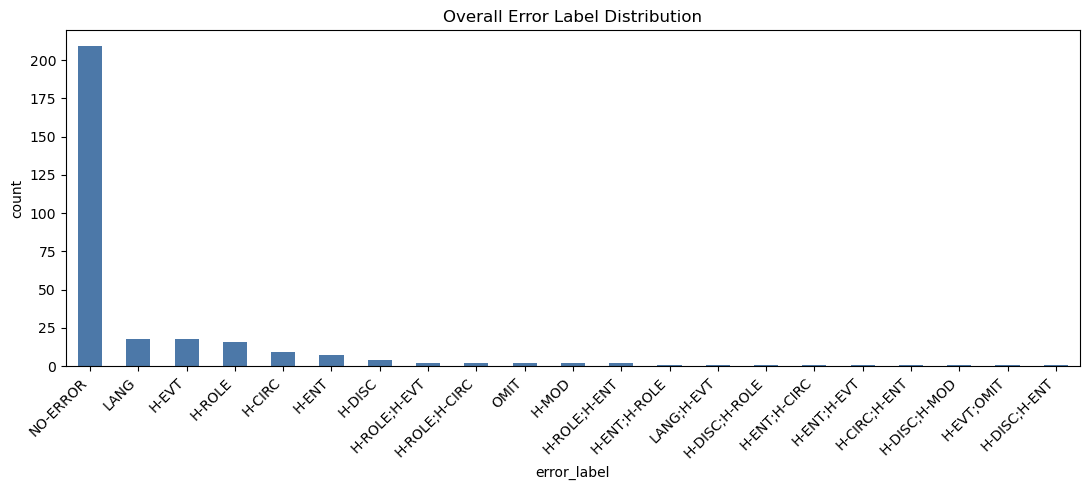

In [4]:
ax = overall.plot.bar(
    x="error_label",
    y="count",
    legend=False,
    figsize=(11, 5),
    color="#4C78A8",
)
ax.set_title("Overall Error Label Distribution")
ax.set_xlabel("error_label")
ax.set_ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

## Model-Wise Row-Level Label Distribution

In [5]:
by_model = (
    df.groupby("model_name")["error_label"]
    .value_counts()
    .rename("count")
    .reset_index()
)
by_model["model_total"] = by_model.groupby("model_name")["count"].transform("sum")
by_model["percent"] = (by_model["count"] / by_model["model_total"] * 100).round(2)
by_model.drop(columns="model_total")

,model_name,error_label,count,percent
0,aya-expanse:8b,NO-ERROR,54,54.0
1,aya-expanse:8b,LANG,17,17.0
2,aya-expanse:8b,H-ROLE,10,10.0
3,aya-expanse:8b,H-CIRC,5,5.0
4,aya-expanse:8b,H-EVT,5,5.0
5,aya-expanse:8b,H-ROLE;H-EVT,2,2.0
6,aya-expanse:8b,H-ENT;H-ROLE,1,1.0
7,aya-expanse:8b,H-ROLE;H-CIRC,1,1.0
8,aya-expanse:8b,LANG;H-EVT,1,1.0
9,aya-expanse:8b,H-DISC;H-ROLE,1,1.0


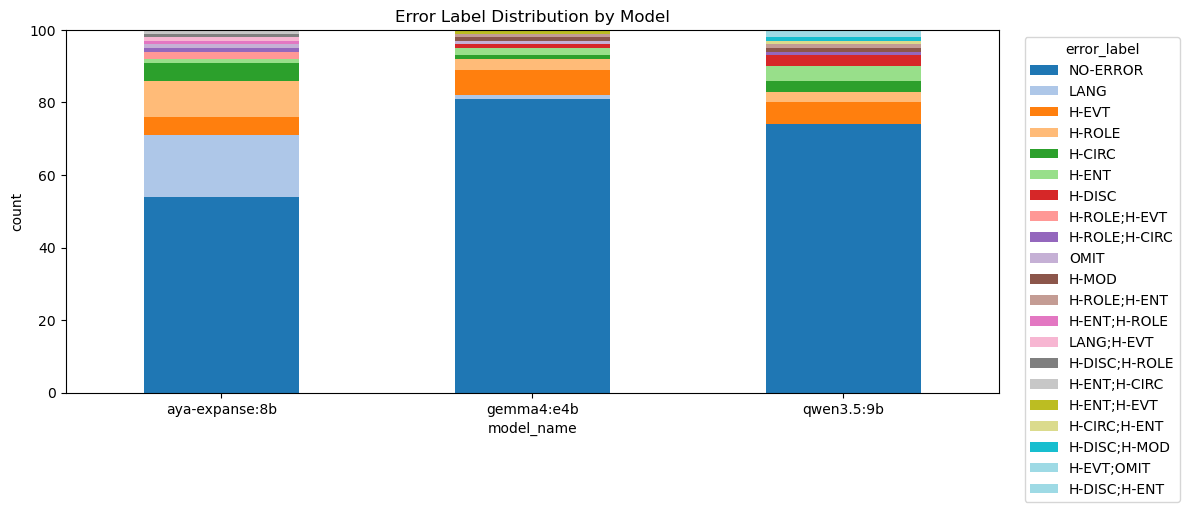

In [6]:
model_pivot = by_model.pivot(index="model_name", columns="error_label", values="count").fillna(0)
model_pivot = model_pivot.reindex(columns=overall["error_label"])

ax = model_pivot.plot.bar(stacked=True, figsize=(12, 5), colormap="tab20")
ax.set_title("Error Label Distribution by Model")
ax.set_xlabel("model_name")
ax.set_ylabel("count")
plt.xticks(rotation=0)
plt.legend(title="error_label", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## Decomposed Taxonomy-Level Counts

Rows with multiple labels are split on `;`, so `OMIT;H-DISC` contributes one count to `OMIT` and one count to `H-DISC`.

In [7]:
decomposed_df = df.assign(label_part=df["error_label"].str.split(";")).explode("label_part")
decomposed_df["label_part"] = decomposed_df["label_part"].str.strip()

decomposed = (
    decomposed_df["label_part"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="occurrences")
)
decomposed

,label,occurrences
0,NO-ERROR,209
1,H-ROLE,24
2,H-EVT,23
3,LANG,19
4,H-ENT,14
5,H-CIRC,13
6,H-DISC,7
7,OMIT,3
8,H-MOD,3


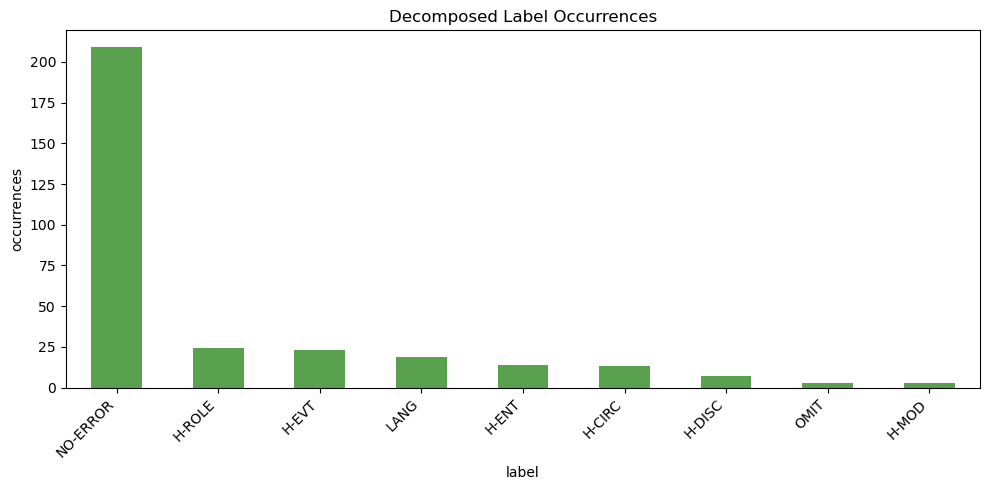

In [8]:
ax = decomposed.plot.bar(
    x="label",
    y="occurrences",
    legend=False,
    figsize=(10, 5),
    color="#59A14F",
)
ax.set_title("Decomposed Label Occurrences")
ax.set_xlabel("label")
ax.set_ylabel("occurrences")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()